# Convergence Speed & Learning Dynamics

Goal: quantify learning speed, slope changes, and stability over time.

Expected takeaway: which methods learn fastest early, which continue improving late, and which plateau.


In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / "combined_wide.csv")
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")
combined["seed"] = combined["seed"].astype(str)

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)


In [2]:
# Compute per-step improvements (discrete derivative)
metrics = ["pass@1", "pass@8", "pass@32", "avg@32"]

# Build derivative table
records = []
for algo in combined["algorithm"].unique():
    sub = agg[agg["algorithm"] == algo].sort_values("Step")
    for metric in metrics:
        y = sub[metric].values
        x = sub["Step"].values
        dy = np.diff(y)
        dx = np.diff(x)
        slope = np.divide(dy, dx, out=np.zeros_like(dy), where=dx!=0)
        for i in range(len(slope)):
            records.append({"algorithm": algo, "Step": x[i+1], "metric": metric, "slope": slope[i]})

slopes = pd.DataFrame(records)


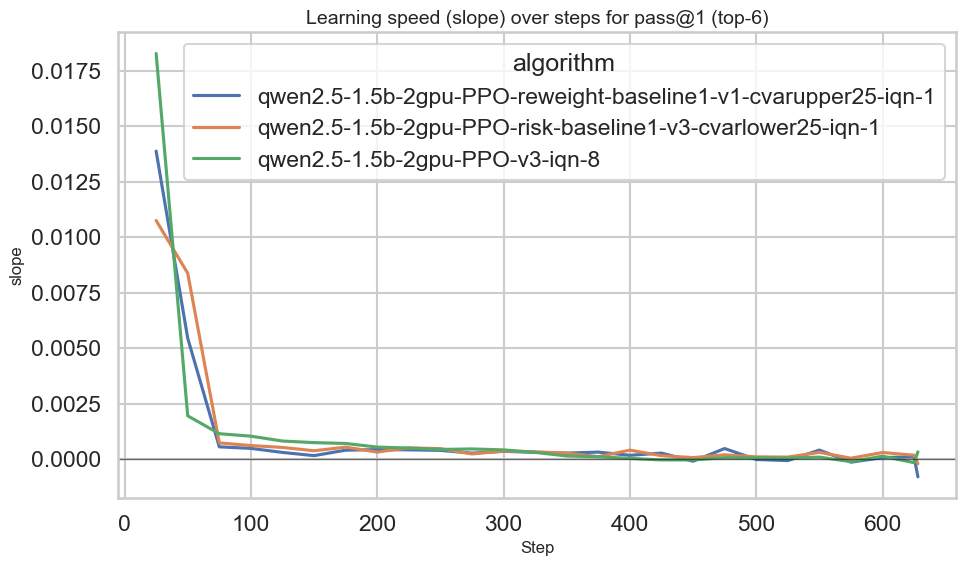

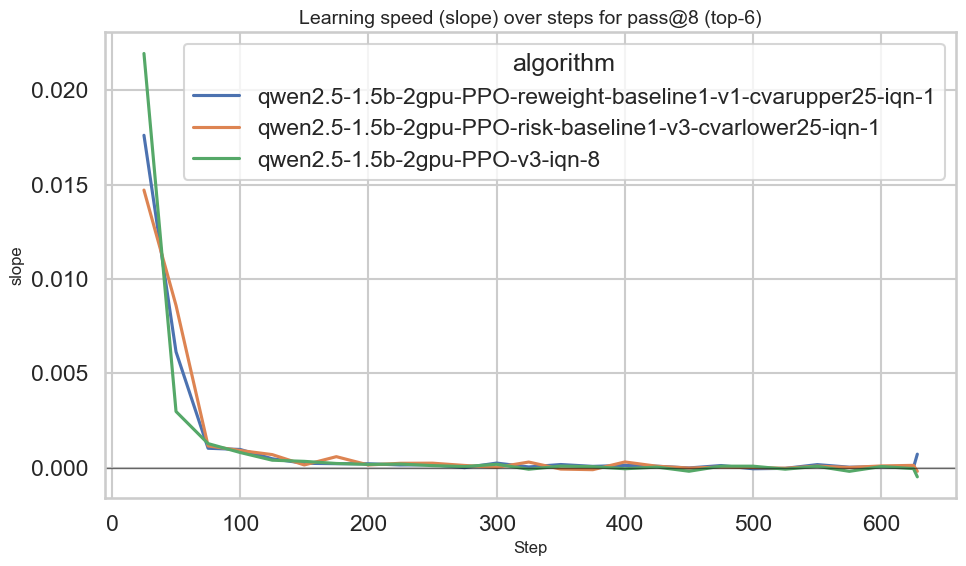

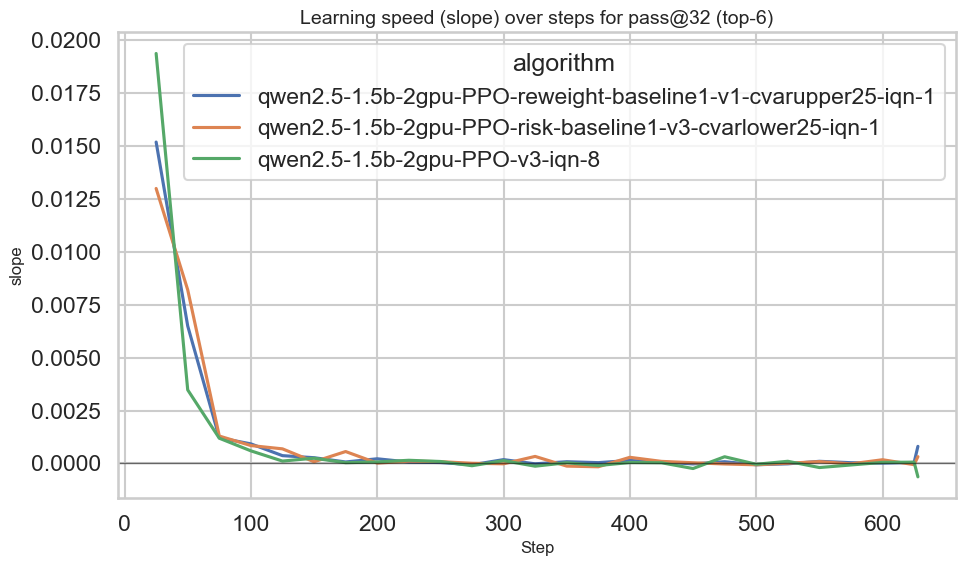

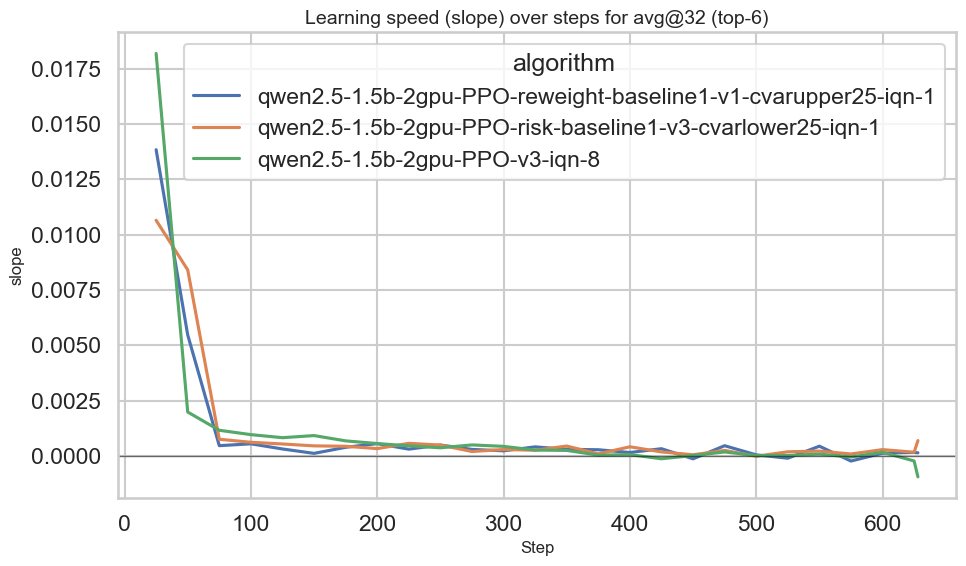

In [3]:
# Plot 1: slope curves (learning speed) for top-6 at final step
for metric in metrics:
    ranking = agg[agg["Step"] == final_step].sort_values(metric, ascending=False)
    tops = ranking["algorithm"].head(6).tolist()
    new_fig(f"Learning speed (slope) over steps for {metric} (top-6)")
    sns.lineplot(data=slopes[slopes["algorithm"].isin(tops) & (slopes["metric"] == metric)], x="Step", y="slope", hue="algorithm")
    plt.axhline(0, color="black", linewidth=1, alpha=0.5)
    plt.tight_layout()
    plt.show()


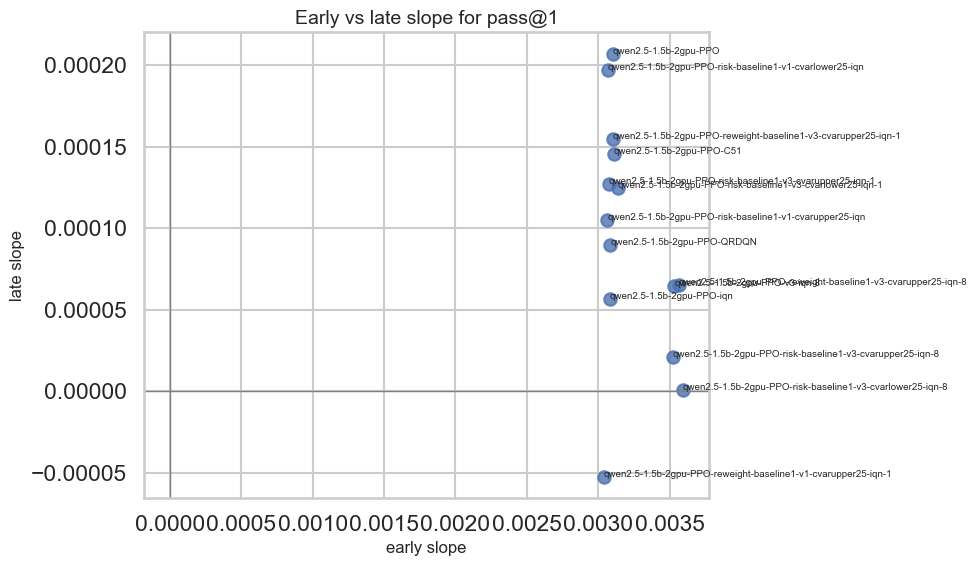

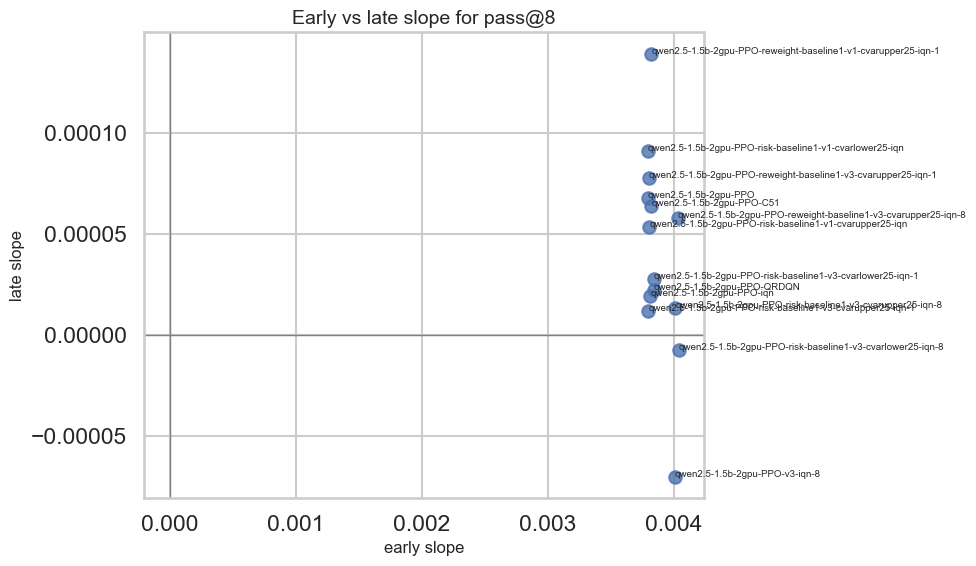

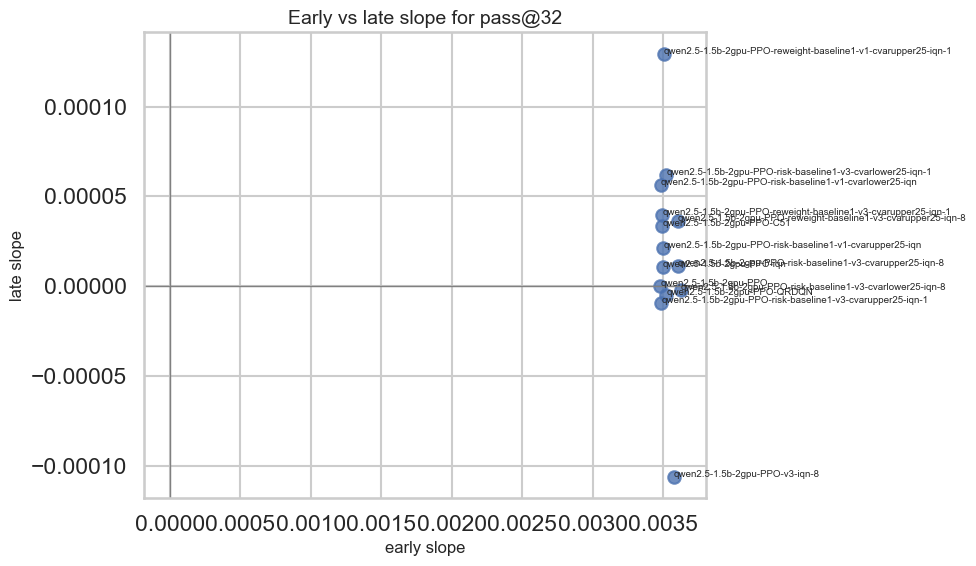

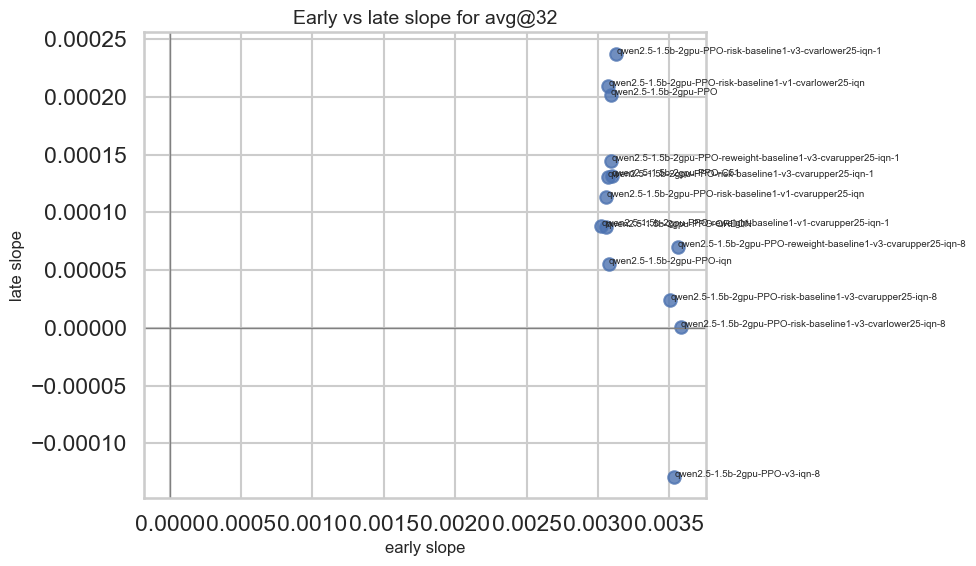

In [4]:
# Plot 2: early vs late slope comparison
# early: first 25% steps, late: last 25% steps
summary = []
steps_sorted = sorted(agg["Step"].unique())
if len(steps_sorted) > 4:
    q1 = steps_sorted[len(steps_sorted)//4]
    q3 = steps_sorted[(len(steps_sorted)*3)//4]
else:
    q1 = steps_sorted[0]
    q3 = steps_sorted[-1]

for metric in metrics:
    for algo in combined["algorithm"].unique():
        sub = slopes[(slopes["algorithm"] == algo) & (slopes["metric"] == metric)]
        early = sub[sub["Step"] <= q1]["slope"].mean()
        late = sub[sub["Step"] >= q3]["slope"].mean()
        summary.append({"algorithm": algo, "metric": metric, "early_slope": early, "late_slope": late})

summary = pd.DataFrame(summary)
for metric in metrics:
    sub = summary[summary["metric"] == metric].copy()
    new_fig(f"Early vs late slope for {metric}")
    plt.scatter(sub["early_slope"], sub["late_slope"], alpha=0.8)
    for _, r in sub.iterrows():
        plt.text(r["early_slope"], r["late_slope"], r["algorithm"], fontsize=7)
    plt.axhline(0, color="gray", linewidth=1)
    plt.axvline(0, color="gray", linewidth=1)
    plt.xlabel("early slope")
    plt.ylabel("late slope")
    plt.tight_layout()
    plt.show()


/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94817/4167677937.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


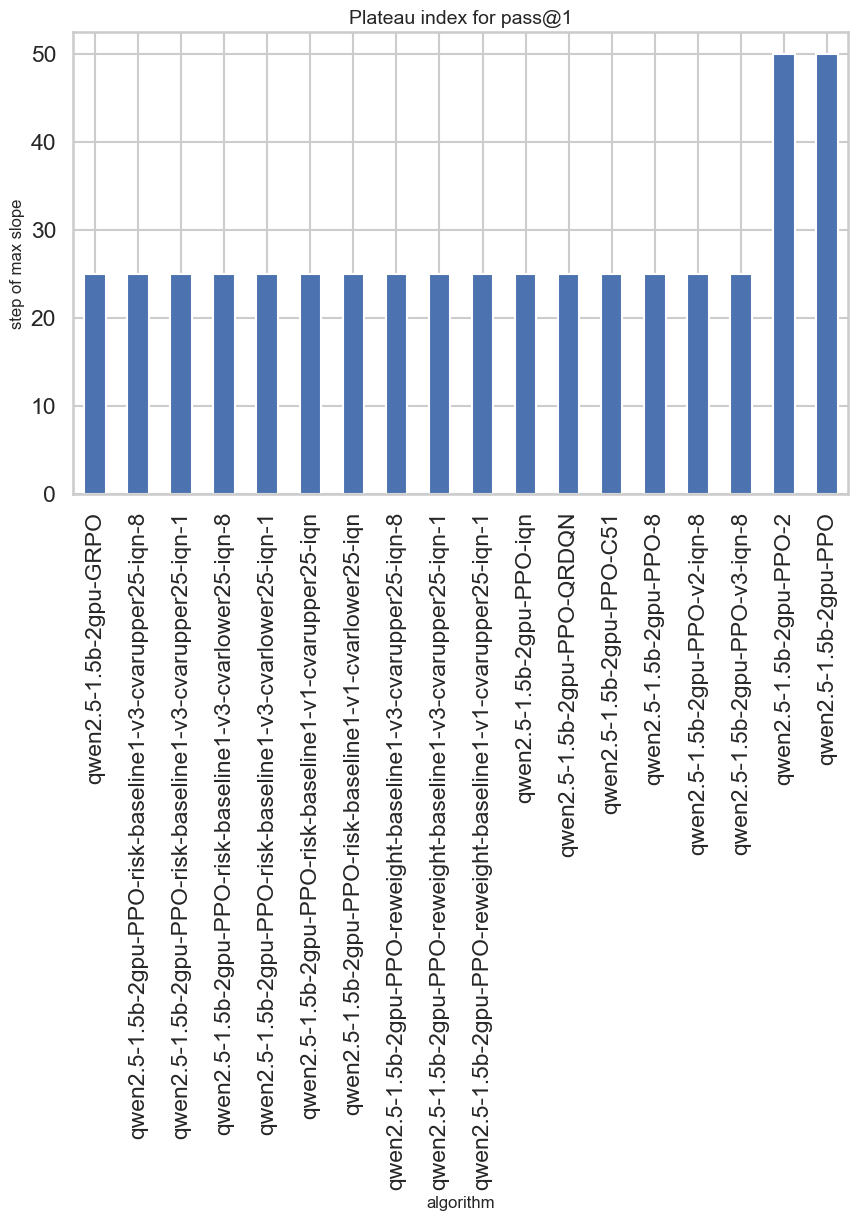

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94817/4167677937.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


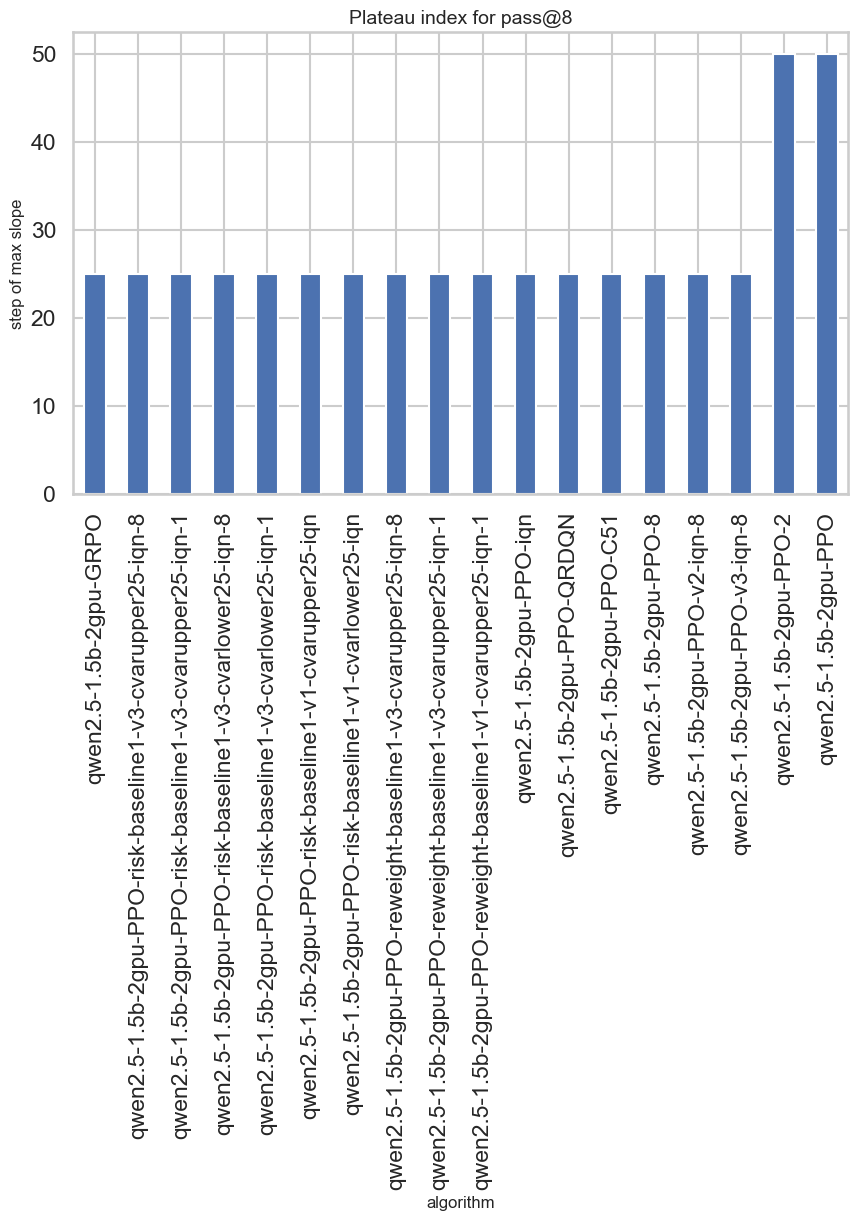

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94817/4167677937.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


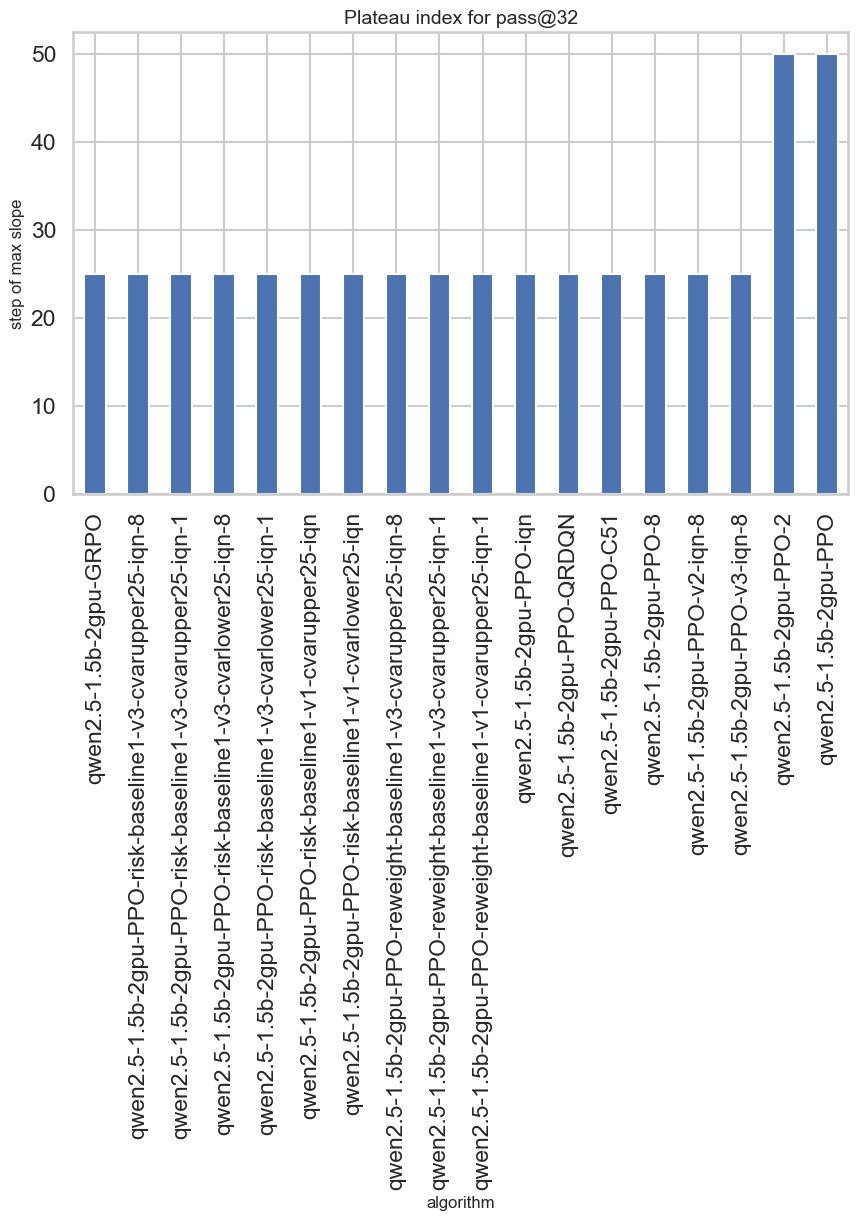

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_94817/4167677937.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


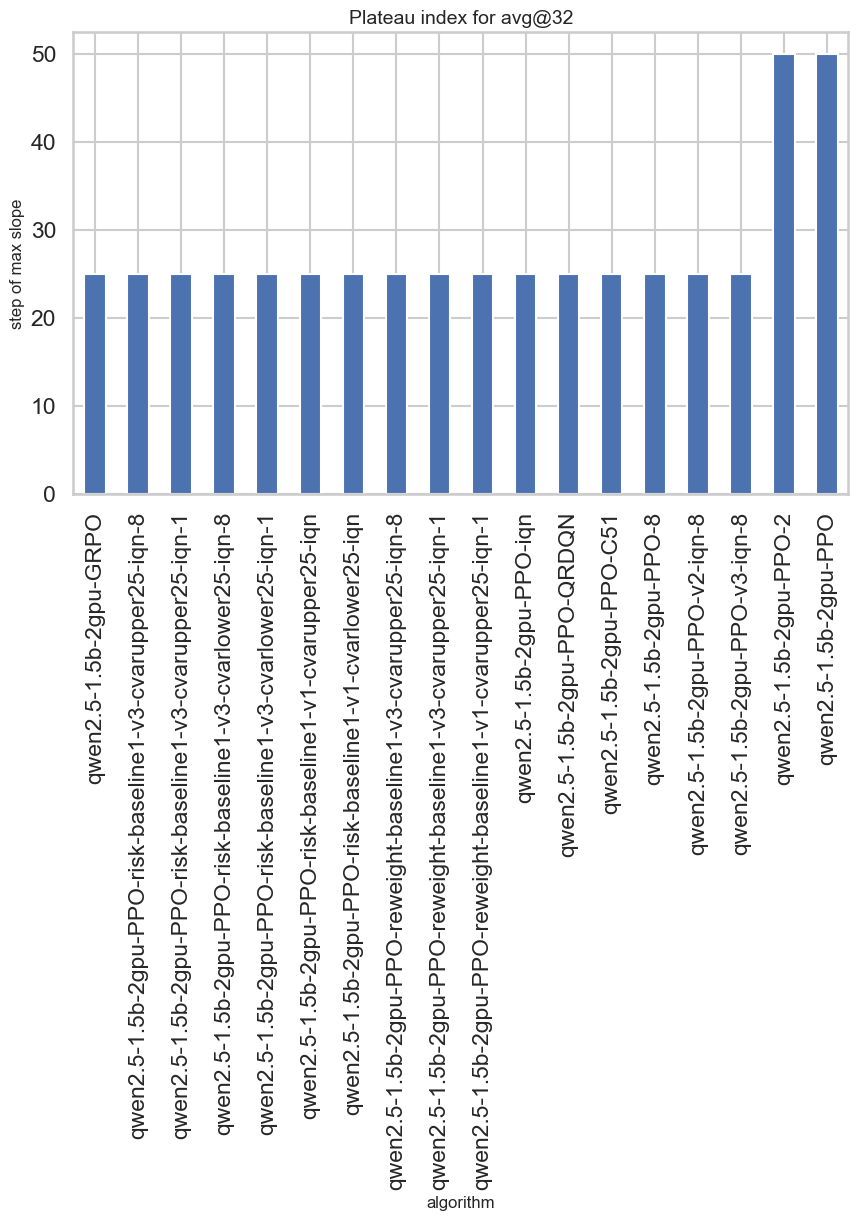

Generated 12 figures


In [5]:
# Plot 3: plateau detection (steps after peak improvement)
for metric in metrics:
    new_fig(f"Plateau index for {metric}")
    plateau = []
    for algo in combined["algorithm"].unique():
        sub = slopes[(slopes["algorithm"] == algo) & (slopes["metric"] == metric)]
        if sub.empty:
            continue
        peak_step = sub.loc[sub["slope"].idxmax(), "Step"]
        plateau.append({"algorithm": algo, "peak_step": peak_step})
    pd.DataFrame(plateau).set_index("algorithm")["peak_step"].sort_values().plot(kind="bar")
    plt.ylabel("step of max slope")
    plt.tight_layout()
    plt.show()

print(f"Generated {PLOT_COUNTER} figures")
